# Análise Exploratória dos dados

In [36]:
%%capture
!pip install xgboost catboost scikit-learn matplotlib seaborn pandas numpy

In [37]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.feature_selection import RFECV
from catboost import CatBoostRegressor
from sklearn.cluster import HDBSCAN
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import os, unicodedata, re
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [38]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto'
file_path = os.path.join(base_dir, 'BD_filerCalcario_versao_1.xlsx')
file = pd.ExcelFile(file_path)
print(file.sheet_names)
scaler = StandardScaler()
clusterer = HDBSCAN(min_cluster_size=2, min_samples=2)

['BD_ML_Resis', 'BD_ML_Slump_1', 'Dicionario_Variaveis']


In [40]:
df_slump = file.parse('BD_ML_Slump_1')
df_slump.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Autores/ano                      126 non-null    object 
 1   ID_Mistura                       126 non-null    object 
 2   Tipo_Cimento_Classe              126 non-null    object 
 3   Massa_Esp_Cimento_g_cm3          110 non-null    float64
 4   Finura_Cimento_Blaine_m2_kg      93 non-null     float64
 5   Massa_Esp_Filer_g_cm3            83 non-null     float64
 6   Finura_Filer_Blaine_m2_kg        65 non-null     float64
 7   Filer_D50_um                     72 non-null     float64
 8   Massa_Esp_Areia_g_cm3            78 non-null     float64
 9   Massa_Esp_Brita_g_cm3            78 non-null     float64
 10  D_Max                            92 non-null     float64
 11  Cimento_kg_m3                    126 non-null    float64
 12  Filer_Calcario_kg_m3  

In [41]:
autores = df_slump['Autores/ano'].unique()

for autor in autores:
    df_autor = df_slump[df_slump['Autores/ano'] == autor]
    print(f"{autor}, Número de amostras: {len(df_autor)} | {df_autor.shape[0]/len(df_slump)*100:.2f}%")

Dos Santos et al, 2024, Número de amostras: 5 | 3.97%
Guemmadi et al, 2009, Número de amostras: 23 | 18.25%
Meddah et al 2014, Número de amostras: 25 | 19.84%
A Morzouki 2016, Número de amostras: 7 | 5.56%
Feltrin 2018, Número de amostras: 12 | 9.52%
Gyu Don Moon 2017, Número de amostras: 8 | 6.35%
Hieu T Cam 2010, Número de amostras: 4 | 3.17%
Md Jahidul Islam 2025, Número de amostras: 5 | 3.97%
Mohammed e Al-Numan (2024), Número de amostras: 5 | 3.97%
Leeuwen et al, (2016), Número de amostras: 10 | 7.94%
Ramezanianpour et al. (2009), Número de amostras: 15 | 11.90%
Bonavetti et al. (2000)., Número de amostras: 2 | 1.59%
Tsivilis et al. (2003), Número de amostras: 5 | 3.97%


In [42]:
encoder_tipo = LabelEncoder()
encoder_substituicao = LabelEncoder()
encoder_empacotamento = LabelEncoder()
encoder_geometria = LabelEncoder()

In [43]:
df_slump['cod_classe'] = encoder_tipo.fit_transform(df_slump['Tipo_Cimento_Classe'])
df_slump['cod_classe'].value_counts()

,count
cod_classe,
6,28
5,25
9,17
0,15
14,10
2,6
12,5
11,4
1,4


In [44]:
df_slump['cod_substituicao'] = encoder_substituicao.fit_transform(df_slump['Metodo_Substituicao'])
df_slump['cod_substituicao'].value_counts()

,count
cod_substituicao,
0,110
1,16


In [45]:
df_slump['cod_empacotamento'] = encoder_empacotamento.fit_transform(df_slump['Metodo_Empacotamento'])
df_slump['cod_empacotamento'].value_counts()

,count
cod_empacotamento,
0,103
1,23


In [46]:
df_slump['cod_geometria'] = encoder_geometria.fit_transform(df_slump['Tipo_Molde_Geometria'])
df_slump['cod_geometria'].value_counts()

,count
cod_geometria,
0,46
3,40
1,30
2,10


/tmp/ipykernel_27507/3852430961.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


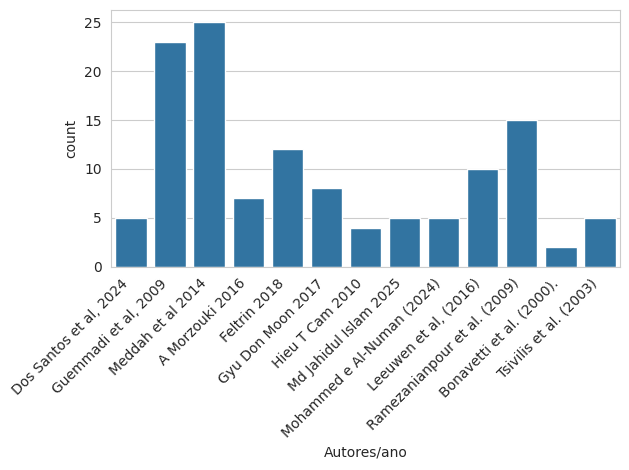

In [47]:
ax = sns.countplot(x='Autores/ano', data=df_slump)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

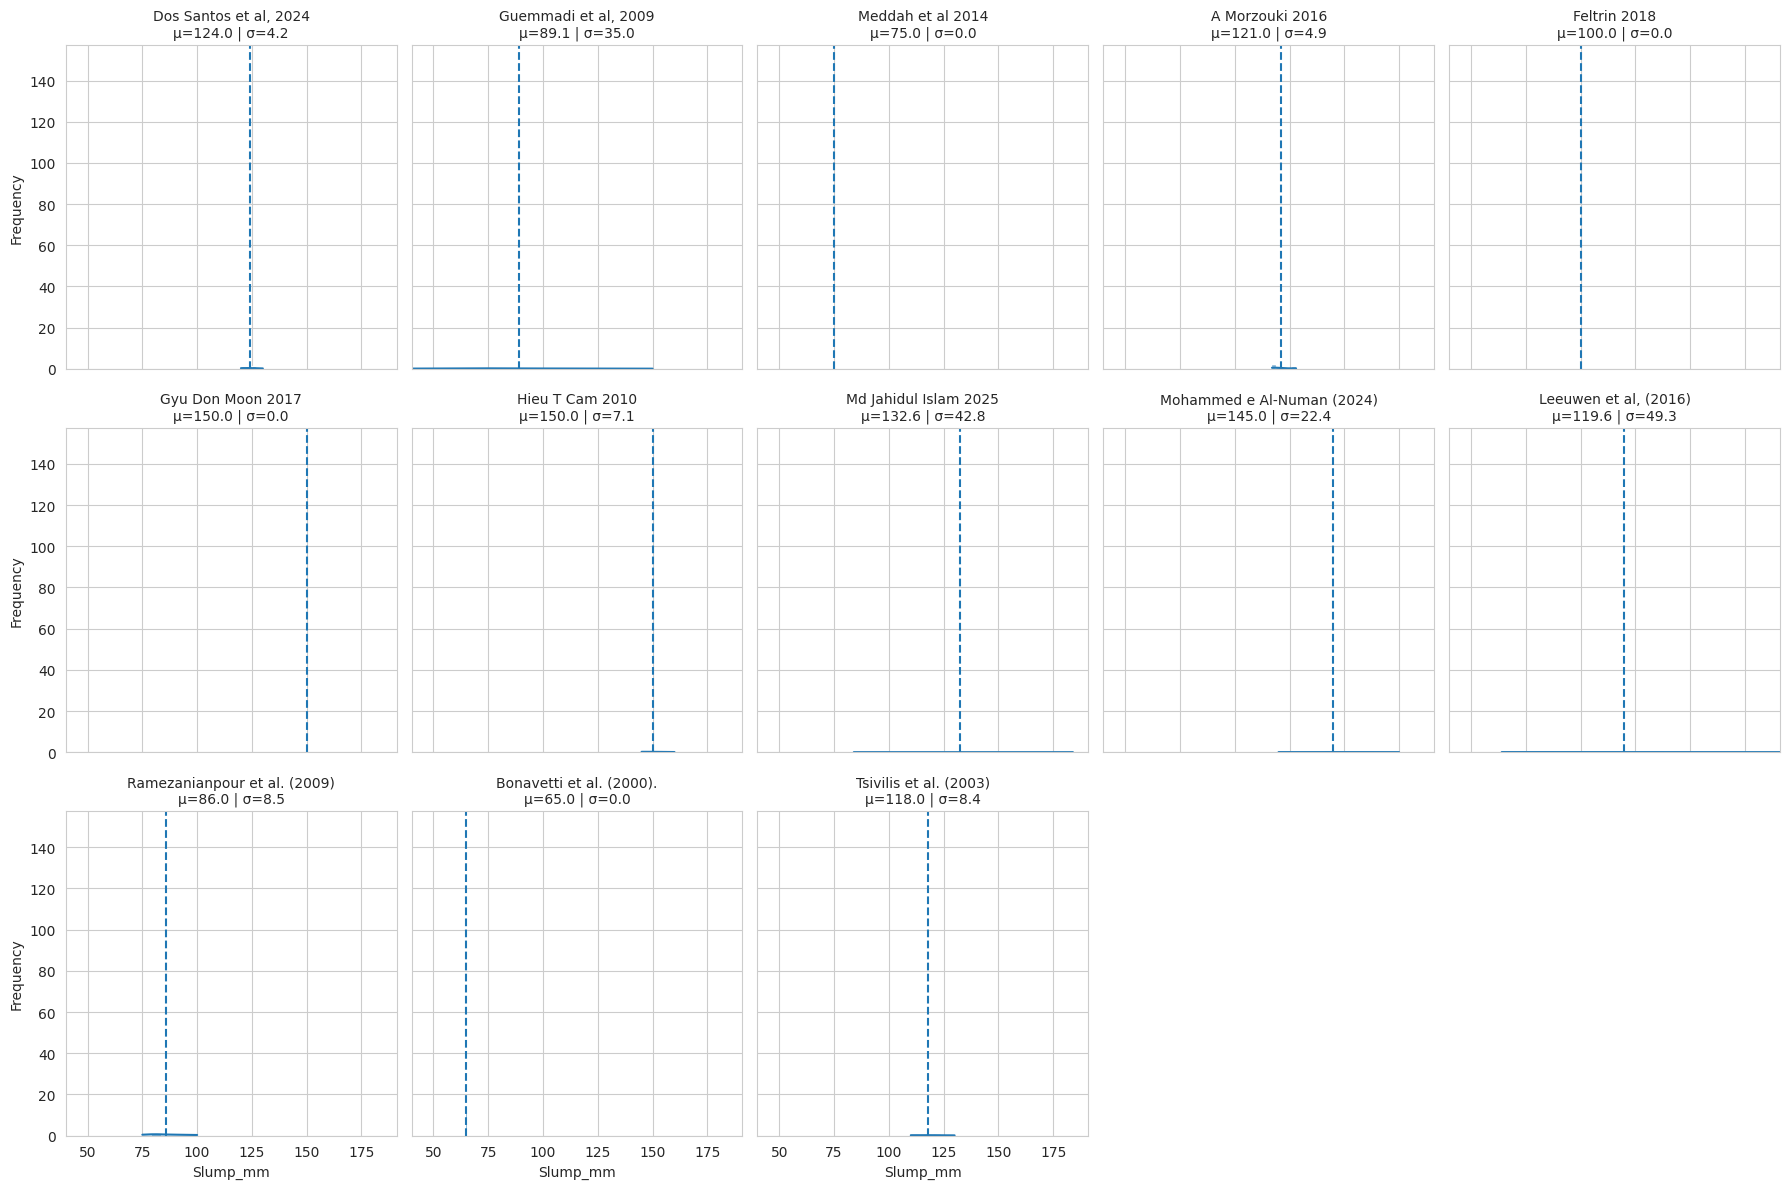

In [48]:
sns.set_style("whitegrid")
autores = df_slump['Autores/ano'].unique()
fig, axes = plt.subplots(
    nrows=3,
    ncols=int(np.ceil(len(autores) / 3)),
    figsize=(18, 4*3),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

xmin = df_slump['Slump_mm'].min()
xmax = df_slump['Slump_mm'].max()

for i, autor in enumerate(autores):

    df_autor = df_slump[
        df_slump['Autores/ano'] == autor
    ]
    media = df_autor['Slump_mm'].mean()
    std = df_autor['Slump_mm'].std()
    sns.histplot(
        data=df_autor,
        x='Slump_mm',
        bins=6,
        kde=True,
        stat='frequency',
        ax=axes[i]
    )
    axes[i].axvline(
        media,
        linestyle='--'
    )
    axes[i].set_title(
        f'{autor}\nμ={media:.1f} | σ={std:.1f}',
        fontsize=10
    )
    axes[i].set_xlim(xmin, xmax)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [49]:
df_slump.groupby('Autores/ano')['Slump_mm'].agg(['count','std'])

,count,std
Autores/ano,,
A Morzouki 2016,7,4.898979
Bonavetti et al. (2000).,2,0.000000
"Dos Santos et al, 2024",5,4.183300
Feltrin 2018,12,0.000000
"Guemmadi et al, 2009",23,35.021168
Gyu Don Moon 2017,8,0.000000
Hieu T Cam 2010,4,7.071068
"Leeuwen et al, (2016)",10,49.313510
Md Jahidul Islam 2025,5,42.787849


In [50]:
df_slump["Usa_SP"] = df_slump["Usa_SP"].astype(bool)

In [51]:
# 1. Preparação das colunas originais
colunas_originais_cluster = [
    'Cimento_kg_m3', 
    'Filer_Calcario_kg_m3', 
    'Agua_kg_m3', 
    'Agregado_Miudo_Total_kg_m3', 
    'Agregado_Graudo_Total_kg_m3', 
    'Superplastificante_kg_m3',
    'Relacao_Agua_Aglomerante'
]

# 2. Tratamento rápido de nulos para o SP
df_slump['Superplastificante_kg_m3'] = df_slump['Superplastificante_kg_m3'].fillna(0)

# 3. Scaling (Mandatório!)
scaler = StandardScaler()
X_originais_scaled = scaler.fit_transform(df_slump[colunas_originais_cluster])

# 4. HDBSCAN
hdbscan_orig = HDBSCAN(
    min_cluster_size=5,
    min_samples=2,
    cluster_selection_epsilon=0.5, # Valor inicial para dados padronizados
    metric='euclidean'
)

df_slump['Cluster_ID'] = hdbscan_orig.fit_predict(X_originais_scaled)

In [ ]:
# Verificando se os clusters fazem sentido para a fluidez (Slump)
analise_slump = df_slump.groupby('Cluster_ID')['Slump_mm'].agg(['mean', 'std', 'count', 'min', 'max'])
print(analise_slump)

In [52]:
df_slump.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Autores/ano                      126 non-null    object 
 1   ID_Mistura                       126 non-null    object 
 2   Tipo_Cimento_Classe              126 non-null    object 
 3   Massa_Esp_Cimento_g_cm3          110 non-null    float64
 4   Finura_Cimento_Blaine_m2_kg      93 non-null     float64
 5   Massa_Esp_Filer_g_cm3            83 non-null     float64
 6   Finura_Filer_Blaine_m2_kg        65 non-null     float64
 7   Filer_D50_um                     72 non-null     float64
 8   Massa_Esp_Areia_g_cm3            78 non-null     float64
 9   Massa_Esp_Brita_g_cm3            78 non-null     float64
 10  D_Max                            92 non-null     float64
 11  Cimento_kg_m3                    126 non-null    float64
 12  Filer_Calcario_kg_m3  

In [53]:
# ==========================================
# CONSTANTES
# ==========================================
# 1. Definimos a lista dos materiais que precisam da correção de densidade
colunas_densidade = [
    'Massa_Esp_Cimento_g_cm3',
    'Massa_Esp_Areia_g_cm3',
    'Massa_Esp_Brita_g_cm3',
    'Massa_Esp_Filer_g_cm3',
    'Superplastificante_kg_m3',
    'D_Max', 'Filer_D50_um',
    'Finura_Cimento_Blaine_m2_kg',
    'Finura_Filer_Blaine_m2_kg',
    'Densidade_Concreto_Fresco_kg_m3'
]

for col in colunas_densidade:
    # Passo A: Imputação com Média do próprio Cluster
    df_slump[col] = df_slump.groupby('Cluster_ID')[col].transform(
        lambda x: x.fillna(x.mean())
    )
    
    # Passo B: A Trava de Segurança (Fallback para a Média Global)
    media_global = df_slump[col].mean()
    df_slump[col] = df_slump[col].fillna(media_global)
    
    # Verificação em tempo real
    nulos_restantes = df_slump[col].isna().sum()
    print(f"✅ {col}: {nulos_restantes} nulos restantes.")

# Tratamento especifico para Superplastificante_kg_m3 que depende diretamente de Usa_SP
df_slump.loc[~df_slump['Usa_SP'], 'Superplastificante_kg_m3'] = 0.0

# Quando não há filler seu tamanho deve ser 0, não faz sentido ter um D50.
df_slump.loc[df_slump['Filer_Calcario_kg_m3'] == 0, 'Filer_D50_um'] = 0.0

df_slump['Massa_Esp_Cimento_kg_m3'] = df_slump['Massa_Esp_Cimento_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump['Massa_Esp_Areia_kg_m3'] =  df_slump['Massa_Esp_Areia_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump['Massa_Esp_Brita_kg_m3'] = df_slump['Massa_Esp_Brita_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump['Massa_Esp_Filer_kg_m3'] = df_slump['Massa_Esp_Filer_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump.drop(columns=['Massa_Esp_Cimento_g_cm3', 'Massa_Esp_Areia_g_cm3', 'Massa_Esp_Brita_g_cm3', 'Massa_Esp_Filer_g_cm3'], inplace=True)

# 2. Atualizando as variáveis que vão alimentar a sua matriz de volumes absolutos
DENSIDADE_CIMENTO = df_slump['Massa_Esp_Cimento_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AREIA = df_slump['Massa_Esp_Areia_kg_m3']  # Usando a coluna já convertida
DENSIDADE_BRITA = df_slump['Massa_Esp_Brita_kg_m3']  # Usando a coluna já convertida
DENSIDADE_FILER = df_slump['Massa_Esp_Filer_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AGUA = 1000
DENSIDADE_SP = 1100

K_AGUA_CIMENTO = 0.22
K_AGUA_FILER = 0.10
K_EQUIV_SP = 15.0
VOID_RATIO_AGREGADOS = 0.35

✅ Massa_Esp_Cimento_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Areia_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Brita_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Filer_g_cm3: 0 nulos restantes.
✅ Superplastificante_kg_m3: 0 nulos restantes.
✅ D_Max: 0 nulos restantes.
✅ Filer_D50_um: 0 nulos restantes.
✅ Finura_Cimento_Blaine_m2_kg: 0 nulos restantes.
✅ Finura_Filer_Blaine_m2_kg: 0 nulos restantes.
✅ Densidade_Concreto_Fresco_kg_m3: 0 nulos restantes.


In [54]:
EPS = np.finfo(float).eps

# ==========================================
# 1. TRATAMENTO DE DADOS
# ==========================================
df_slump['Superplastificante_kg_m3'] = df_slump['Superplastificante_kg_m3'].fillna(0)
df_slump.drop(['Filer_D50_um'], axis=1, inplace=True, errors='ignore')
df_slump['D_Max'] = df_slump['D_Max'].fillna(df_slump['D_Max'].median())

# ==========================================
# 2. CONVERSÃO MASSA → VOLUME (m³/m³)
# ==========================================
df_slump['vol_cimento'] = pd.to_numeric(df_slump['Cimento_kg_m3'], errors='coerce') / DENSIDADE_CIMENTO
df_slump['vol_filer'] = pd.to_numeric(df_slump['Filer_Calcario_kg_m3'], errors='coerce') / DENSIDADE_FILER
df_slump['vol_agua'] = pd.to_numeric(df_slump['Agua_kg_m3'], errors='coerce') / DENSIDADE_AGUA
df_slump['vol_areia'] = pd.to_numeric(df_slump['Agregado_Miudo_Total_kg_m3'], errors='coerce') / DENSIDADE_AREIA
df_slump['vol_brita'] = pd.to_numeric(df_slump['Agregado_Graudo_Total_kg_m3'], errors='coerce') / DENSIDADE_BRITA
df_slump['vol_sp'] = pd.to_numeric(df_slump['Superplastificante_kg_m3'], errors='coerce') / DENSIDADE_SP

# ==========================================
# 3. FECHAMENTO VOLUMÉTRICO
# ==========================================
volume_materiais = (
    df_slump['vol_cimento'] + df_slump['vol_filer'] + df_slump['vol_agua'] +
    df_slump['vol_areia'] + df_slump['vol_brita'] + df_slump['vol_sp']
)

df_slump['vol_ar_aprisionado'] = (1.0 - volume_materiais).clip(lower=0)

# ==========================================
# 4. AGRUPAMENTOS
# ==========================================
df_slump['vol_aglomerante'] = df_slump['vol_cimento'] + df_slump['vol_filer']
df_slump['vol_agregados'] = df_slump['vol_areia'] + df_slump['vol_brita']

df_slump['vol_pasta'] = (
    df_slump['vol_aglomerante'] +
    df_slump['vol_agua'] +
    df_slump['vol_sp'] +
    df_slump['vol_ar_aprisionado']
)

df_slump['vol_argamassa'] = df_slump['vol_pasta'] + df_slump['vol_areia']

# 🔧 Correção: evitar propagação de erro numérico
df_slump['vol_total'] = 1.0

# ==========================================
# 5. ÁGUA EFETIVA
# ==========================================
df_slump['massa_aglomerante_total'] = (
    df_slump['Cimento_kg_m3'] + df_slump['Filer_Calcario_kg_m3']
)

agua_adsorvida = (
    K_AGUA_CIMENTO * df_slump['Cimento_kg_m3'] +
    K_AGUA_FILER * df_slump['Filer_Calcario_kg_m3']
)

df_slump['vol_agua_livre'] = (
    (df_slump['Agua_kg_m3'] - agua_adsorvida).clip(lower=0)
) / DENSIDADE_AGUA

# ==========================================
# 6. FRAÇÕES
# ==========================================
df_slump['fracao_vol_pasta'] = df_slump['vol_pasta']
df_slump['fracao_vol_argamassa'] = df_slump['vol_argamassa']

# ==========================================
# 7. RELAÇÕES
# ==========================================
df_slump['agua_aglomerante_vol'] = df_slump['vol_agua'] / df_slump['vol_aglomerante'].clip(lower=EPS)

df_slump['relacao_areia_brita_vol'] = df_slump['vol_areia'] / df_slump['vol_brita'].clip(lower=EPS)

df_slump['fator_areia_agregado'] = df_slump['vol_areia'] / df_slump['vol_agregados'].clip(lower=EPS)

# 🔧 Correção: agora representa melhor pasta vs esqueleto granular
df_slump['teor_pasta_relativo'] = df_slump['vol_pasta'] / df_slump['vol_agregados'].clip(lower=EPS)

df_slump['filer_sobre_cimento_vol'] = df_slump['vol_filer'] / df_slump['vol_cimento'].clip(lower=EPS)

# ==========================================
# 8. LUBRIFICAÇÃO
# ==========================================
df_slump['agua_equivalente_vol'] = df_slump['vol_agua'] + K_EQUIV_SP * df_slump['vol_sp']

df_slump['indice_lubrificacao_global'] = (
    df_slump['agua_equivalente_vol'] / df_slump['vol_brita'].clip(lower=EPS)
)

# ==========================================
# 9. REOLOGIA
# ==========================================
df_slump['particle_crowding_index'] = (
    df_slump['vol_agregados'] / df_slump['vol_pasta'].clip(lower=EPS)
)

# 🔧 Correção: não pode ser negativo
df_slump['vol_pasta_livre'] = (
    df_slump['vol_pasta'] - VOID_RATIO_AGREGADOS * df_slump['vol_agregados']
).clip(lower=0)

# 🔧 Correção: área mais coerente fisicamente
df_slump['area_superficial_proxy'] = (
    df_slump['vol_areia'] / 0.2 +   # D_areia ~ 0.2 mm
    df_slump['vol_brita'] / df_slump['D_Max'].clip(lower=EPS)
)

df_slump['paste_film_thickness'] = (
    df_slump['vol_pasta_livre'] / df_slump['area_superficial_proxy'].clip(lower=EPS)
)

df_slump['rigidez_pasta'] = (
    df_slump['vol_aglomerante'] / df_slump['agua_equivalente_vol'].clip(lower=EPS)
)

df_slump['yield_stress_proxy'] = (
    df_slump['rigidez_pasta'] * df_slump['particle_crowding_index']
)

# ==========================================
# 10. SEGREGAÇÃO
# ==========================================
df_slump['agua_sobre_areia'] = df_slump['vol_agua'] / df_slump['vol_areia'].clip(lower=EPS)

df_slump['potencial_segregacao'] = (
    df_slump['agua_sobre_areia'] / df_slump['teor_pasta_relativo'].clip(lower=EPS)
)

# ==========================================
# 11. FEATURES FINAIS
# ==========================================
df_slump['fluido_lubrificante_total'] = (
    df_slump['vol_agua'] + df_slump['vol_ar_aprisionado']
)

df_slump['vol_finos_reconstruido'] = (
    df_slump['teor_pasta_relativo'] * df_slump['vol_agregados']
)

df_slump['fator_agua_finos'] = (
    df_slump['vol_agua'] / df_slump['vol_finos_reconstruido'].clip(lower=EPS)
)

df_slump['lubrificacao_efetiva'] = (
    df_slump['indice_lubrificacao_global'] /
    (1 + df_slump['potencial_segregacao'])
)

# ==========================================
# 12. LEIS CLÁSSICAS (ABRAMS, LYSE, MOLINARI)
# ==========================================

# --- LEI DE ABRAMS (Qualidade e Fluidez da Pasta) ---
# Representa a mobilidade potencial. Quanto maior o w/c, maior o potencial de Slump.
df_slump['abrams_mobility_factor'] = np.exp(df_slump['Relacao_Agua_Aglomerante'])

# --- LEI DE LYSE (Volume de Água e Sólidos) ---
# Lyse puro: Água por volume de sólidos (Cimento + Filer + Areia + Brita)
vol_solidos = (df_slump['vol_cimento'] + df_slump['vol_filer'] + 
               df_slump['vol_areia'] + df_slump['vol_brita'])

df_slump['lyse_water_demand'] = df_slump['vol_agua'] / vol_solidos.clip(lower=EPS)

# --- LEI DE MOLINARI (Teor de Argamassa - Alpha) ---
# Representa a proporção de matriz fina que "carrega" a brita. 
# Essencial para a trabalhabilidade.
df_slump['molinari_alpha'] = df_slump['vol_argamassa'] / df_slump['vol_total']

# Uma mistura das três: Água de Lyse ajustada pelo Alpha de Molinari
df_slump['reologia_global_proxy'] = (df_slump['lyse_water_demand'] * df_slump['molinari_alpha'] * df_slump['abrams_mobility_factor'])

In [55]:
# Seleção das colunas "Cérebro do Slump"
colunas_cluster_avancado = [
    # 1. Dimensão de Fluidez (Física)
    'paste_film_thickness',   # Espessura da camada lubrificante
    'yield_stress_proxy',     # Tensão de escoamento (o "divisor" entre sólido e fluido)
    
    # 2. Dimensão de Estrutura (Leis de Molinari e Abrams)
    'molinari_alpha',         # Teor de argamassa (separa concretos "pedrentos" de "melados")
    'fator_areia_agregado',   # Esqueleto granular (crucial para o Slump)
    
    # 3. Dimensão de Intensidade (Lei de Lyse e Química)
    'lyse_water_demand',      # A "Lei de Ouro" do Slump: água por volume de sólidos
    'lubrificacao_efetiva'    # O efeito real do superplastificante + água
]

X_cluster = df_slump[colunas_cluster_avancado].copy()

# O StandardScaler aqui é ainda mais crítico devido às transformações físicas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

hdbscan_modelo = HDBSCAN(
    min_cluster_size=5, 
    min_samples=2,
    cluster_selection_epsilon=0.3, # Reduzi um pouco para ser mais criterioso com as novas features
    metric='euclidean'
)

df_slump['Cluster_ID'] = hdbscan_modelo.fit_predict(X_scaled)

In [56]:
# Verificando se os clusters fazem sentido para a fluidez (Slump)
analise_slump = df_slump.groupby('Cluster_ID')['Slump_mm'].agg(['mean', 'std', 'count', 'min', 'max'])
print(analise_slump)

                  mean        std  count  min  max
Cluster_ID                                        
-1          120.000000  23.237900     16   80  160
 0           78.000000   2.738613      5   75   80
 1           84.000000   4.183300      5   80   90
 2          132.600000  42.787849      5   84  184
 3           96.000000   4.183300      5   90  100
 4          145.000000  22.360680      5  120  175
 5          119.600000  49.313510     10   64  191
 6          102.000000   4.472136      5  100  110
 7           75.000000   0.000000      5   75   75
 8          150.000000   0.000000      8  150  150
 9           88.333333  18.073922      6   65  100
 10          86.842105  37.275645     19   40  150
 11          79.166667  10.206207      6   75  100
 12         121.000000   4.898979      7  117  128
 13          75.000000   0.000000      5   75   75
 14          87.857143  21.457855     14   75  130


In [57]:
ALVO = 'Slump_mm' 

whitelist_features = [
    'Usa_SP',
    'D_Max',
    'fracao_vol_pasta',
    # DEFINIR COLUNAS DE FILLER QUE SÃO CRUCIAIS PARA O MODELO, MESMO QUE TENHAM ALTA CORRELAÇÃO ENTRE SI
    'vol_ar_aprisionado',
    'rigidez_pasta',
    'yield_stress_proxy',
    'lubrificacao_efetiva'
]

# 1. Correlação
corr_matrix = df_slump.corr(method='spearman', numeric_only=True).abs()
corr_com_alvo = corr_matrix[ALVO].drop(ALVO)

limite_colinearidade = 0.95
features_para_remover = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]

        if col_i == ALVO or col_j == ALVO:
            continue

        if corr_matrix.iloc[i, j] > limite_colinearidade:

            if col_i in whitelist_features and col_j in whitelist_features:
                continue
            elif col_i in whitelist_features and col_j not in whitelist_features:
                features_para_remover.add(col_j)
                continue
            elif col_j in whitelist_features and col_i not in whitelist_features:
                features_para_remover.add(col_i)
                continue

            # lógica original
            if corr_com_alvo[col_i] > corr_com_alvo[col_j]:
                features_para_remover.add(col_j)
            else:
                features_para_remover.add(col_i)

print(f"Features removidas por colinearidade: {features_para_remover}")

df_filtrado = df_slump.drop(columns=features_para_remover)

Features removidas por colinearidade: {'vol_filer', 'fator_areia_agregado', 'Superplastificante_kg_m3', 'abrams_mobility_factor', 'area_superficial_proxy', 'filer_sobre_cimento_vol', 'ln_Idade', 'vol_agua', 'molinari_alpha', 'vol_pasta', 'Agregado_Miudo_Total_kg_m3', 'vol_pasta_livre', 'vol_areia', 'particle_crowding_index', 'Classe_Cim_OpB', 'paste_film_thickness', 'cod_substituicao', 'cod_empacotamento', 'Agregado_Graudo_Total_kg_m3', 'Cimento_kg_m3', 'vol_finos_reconstruido', 'teor_pasta_relativo', 'Relacao_Agua_Aglomerante', 'Superplast_%_cement', 'vol_sp', 'cod_geometria', 'fracao_vol_argamassa'}


In [58]:
df_filtrado.columns

Index(['Autores/ano', 'ID_Mistura', 'Tipo_Cimento_Classe',
       'Finura_Cimento_Blaine_m2_kg', 'Finura_Filer_Blaine_m2_kg', 'D_Max',
       'Filer_Calcario_kg_m3', 'Agua_kg_m3', 'Relacao_Agua_Cimento',
       'Metodo_Empacotamento', 'Metodo_Substituicao', 'Idade_Dias', 'Slump_mm',
       'Densidade_Concreto_Fresco_kg_m3', 'Tipo_Molde_Geometria',
       'Resistencia_Compressao_MPa', 'Tipo_Molde_Cod', 'Classe_Cim_OpA',
       'Metodo_Emp_Cod', 'Metodo_Sub_Cod', 'Usa_SP', 'cod_classe',
       'Cluster_ID', 'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Areia_kg_m3',
       'Massa_Esp_Brita_kg_m3', 'Massa_Esp_Filer_kg_m3', 'vol_cimento',
       'vol_brita', 'vol_ar_aprisionado', 'vol_aglomerante', 'vol_agregados',
       'vol_argamassa', 'vol_total', 'massa_aglomerante_total',
       'vol_agua_livre', 'fracao_vol_pasta', 'agua_aglomerante_vol',
       'relacao_areia_brita_vol', 'agua_equivalente_vol',
       'indice_lubrificacao_global', 'rigidez_pasta', 'yield_stress_proxy',
       'agua_sobre_a

In [59]:
df_filtrado.corr(method='spearman', numeric_only=True)['Slump_mm'].abs().sort_values(ascending=False)

,Slump_mm
Slump_mm,1.000000
Tipo_Molde_Cod,0.587067
vol_argamassa,0.482950
vol_brita,0.421702
fluido_lubrificante_total,0.410334
Massa_Esp_Filer_kg_m3,0.398080
lubrificacao_efetiva,0.397635
vol_agregados,0.380928
relacao_areia_brita_vol,0.355258
potencial_segregacao,0.350659


In [60]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 50 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Autores/ano                      126 non-null    object 
 1   ID_Mistura                       126 non-null    object 
 2   Tipo_Cimento_Classe              126 non-null    object 
 3   Finura_Cimento_Blaine_m2_kg      126 non-null    float64
 4   Finura_Filer_Blaine_m2_kg        126 non-null    float64
 5   D_Max                            126 non-null    float64
 6   Filer_Calcario_kg_m3             126 non-null    float64
 7   Agua_kg_m3                       126 non-null    float64
 8   Relacao_Agua_Cimento             126 non-null    float64
 9   Metodo_Empacotamento             126 non-null    object 
 10  Metodo_Substituicao              110 non-null    object 
 11  Idade_Dias                       126 non-null    int64  
 12  Slump_mm              

In [61]:
df_filtrado.drop(columns=["Metodo_Empacotamento", "Metodo_Substituicao", "Tipo_Cimento_Classe", "ID_Mistura", "Tipo_Molde_Geometria"], inplace=True)

In [ ]:
# 1. Preparando os dados e ISOLANDO o Grupo
grupos_isolamento = df_filtrado['Autores/ano'].copy()

# O Autores/ano é removido de X junto com o ALVO
X = df_filtrado.drop(columns=[ALVO, 'Autores/ano']).copy()
y = df_filtrado[ALVO]

nome_modelo = "CatBoost"

# 2. Dicionário de Modelos
modelos = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=False, thread_count=-1),
    "HGBR": GradientBoostingRegressor(random_state=42) 
}

# Tratamentos Específicos
if nome_modelo == "HGBR":
    X.fillna(X.select_dtypes(include='number').mean(), inplace=True)

if nome_modelo == "XGBoost":
    # Captura e dropa apenas as colunas categóricas que sobraram
    categorical_cols = X.select_dtypes(include=['object']).columns
    X.drop(columns=categorical_cols, inplace=True)  

resultados_selecao = {}

# 3. O Loop de Automação
estimador = modelos[nome_modelo]
print(f"⏳ Rodando RFECV para o modelo: {nome_modelo}...")

seletor_rfecv = RFECV(
    estimator=estimador, 
    step=1, 
    cv=GroupKFold(n_splits=grupos_isolamento.nunique()),  # Garantindo que cada grupo fique inteiro em um fold
    scoring='r2',
    min_features_to_select=5,
    n_jobs=-1
)

# Treina o seletor injetando a série separada no parâmetro 'groups'
seletor_rfecv.fit(X, y, groups=grupos_isolamento)

# Salva as features
features_sobreviventes = list(X.columns[seletor_rfecv.support_])

resultados_selecao[nome_modelo] = {
    "Qtd_Otimizada": seletor_rfecv.n_features_,
    "Features_Selecionadas": features_sobreviventes
}

print(f"✅ {nome_modelo} finalizado! Elegeu {seletor_rfecv.n_features_} features.\n")

# Para o DF Final, mantemos o ALVO e também o Autores/ano (caso precise no futuro)
df_final = df_filtrado[resultados_selecao[nome_modelo]["Features_Selecionadas"] + [ALVO] + ['Autores/ano']]

⏳ Rodando RFECV para o modelo: CatBoost...


In [ ]:
features_sobreviventes

['Finura_Cimento_Blaine_m2_kg',
 'Finura_Filer_Blaine_m2_kg',
 'D_Max',
 'Filer_Calcario_kg_m3',
 'Relacao_Agua_Cimento',
 'Idade_Dias',
 'Densidade_Concreto_Fresco_kg_m3',
 'Resistencia_Compressao_MPa',
 'Tipo_Molde_Cod',
 'Classe_Cim_OpA',
 'Metodo_Sub_Cod',
 'Usa_SP',
 'cod_classe',
 'Cluster_ID',
 'Massa_Esp_Cimento_kg_m3',
 'Massa_Esp_Areia_kg_m3',
 'Massa_Esp_Brita_kg_m3',
 'Massa_Esp_Filer_kg_m3',
 'vol_cimento',
 'vol_brita',
 'vol_ar_aprisionado',
 'vol_aglomerante',
 'vol_agregados',
 'vol_argamassa',
 'vol_total',
 'massa_aglomerante_total',
 'vol_agua_livre',
 'fracao_vol_pasta',
 'agua_aglomerante_vol',
 'relacao_areia_brita_vol',
 'agua_equivalente_vol',
 'indice_lubrificacao_global',
 'rigidez_pasta',
 'yield_stress_proxy',
 'agua_sobre_areia',
 'potencial_segregacao',
 'fluido_lubrificante_total',
 'fator_agua_finos',
 'lubrificacao_efetiva',
 'lyse_water_demand',
 'reologia_global_proxy']

In [ ]:
df_final['Usa_SP'] = df_final['Usa_SP'].astype(np.int8)

/tmp/ipykernel_27507/1412401073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Usa_SP'] = df_final['Usa_SP'].astype(np.int8)


In [ ]:
columns = df_final.columns

outliers_idx = {}
for column in columns:
    if df_final[column].dtype == 'object' or column == 'Usa_SP':
        continue
    data = df_final[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_idx[column] = data[(data < lower_bound) | (data > upper_bound)].index.tolist()

for column, idx in sorted(outliers_idx.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{column}: {len(idx)} outliers")

massa_aglomerante_total: 55 outliers
D_Max: 37 outliers
vol_aglomerante: 37 outliers
Massa_Esp_Areia_kg_m3: 35 outliers
Idade_Dias: 28 outliers
agua_equivalente_vol: 18 outliers
Metodo_Sub_Cod: 16 outliers
Massa_Esp_Brita_kg_m3: 15 outliers
indice_lubrificacao_global: 15 outliers
relacao_areia_brita_vol: 14 outliers
lubrificacao_efetiva: 14 outliers
Finura_Filer_Blaine_m2_kg: 13 outliers
vol_argamassa: 13 outliers
Massa_Esp_Cimento_kg_m3: 12 outliers
vol_ar_aprisionado: 12 outliers
fator_agua_finos: 11 outliers
Finura_Cimento_Blaine_m2_kg: 10 outliers
yield_stress_proxy: 10 outliers
Densidade_Concreto_Fresco_kg_m3: 8 outliers
Massa_Esp_Filer_kg_m3: 8 outliers
fluido_lubrificante_total: 8 outliers
fracao_vol_pasta: 5 outliers
lyse_water_demand: 5 outliers
reologia_global_proxy: 5 outliers
vol_brita: 4 outliers
Relacao_Agua_Cimento: 3 outliers
Filer_Calcario_kg_m3: 2 outliers
vol_cimento: 2 outliers
agua_aglomerante_vol: 2 outliers
Resistencia_Compressao_MPa: 0 outliers
Tipo_Molde_Cod: 0

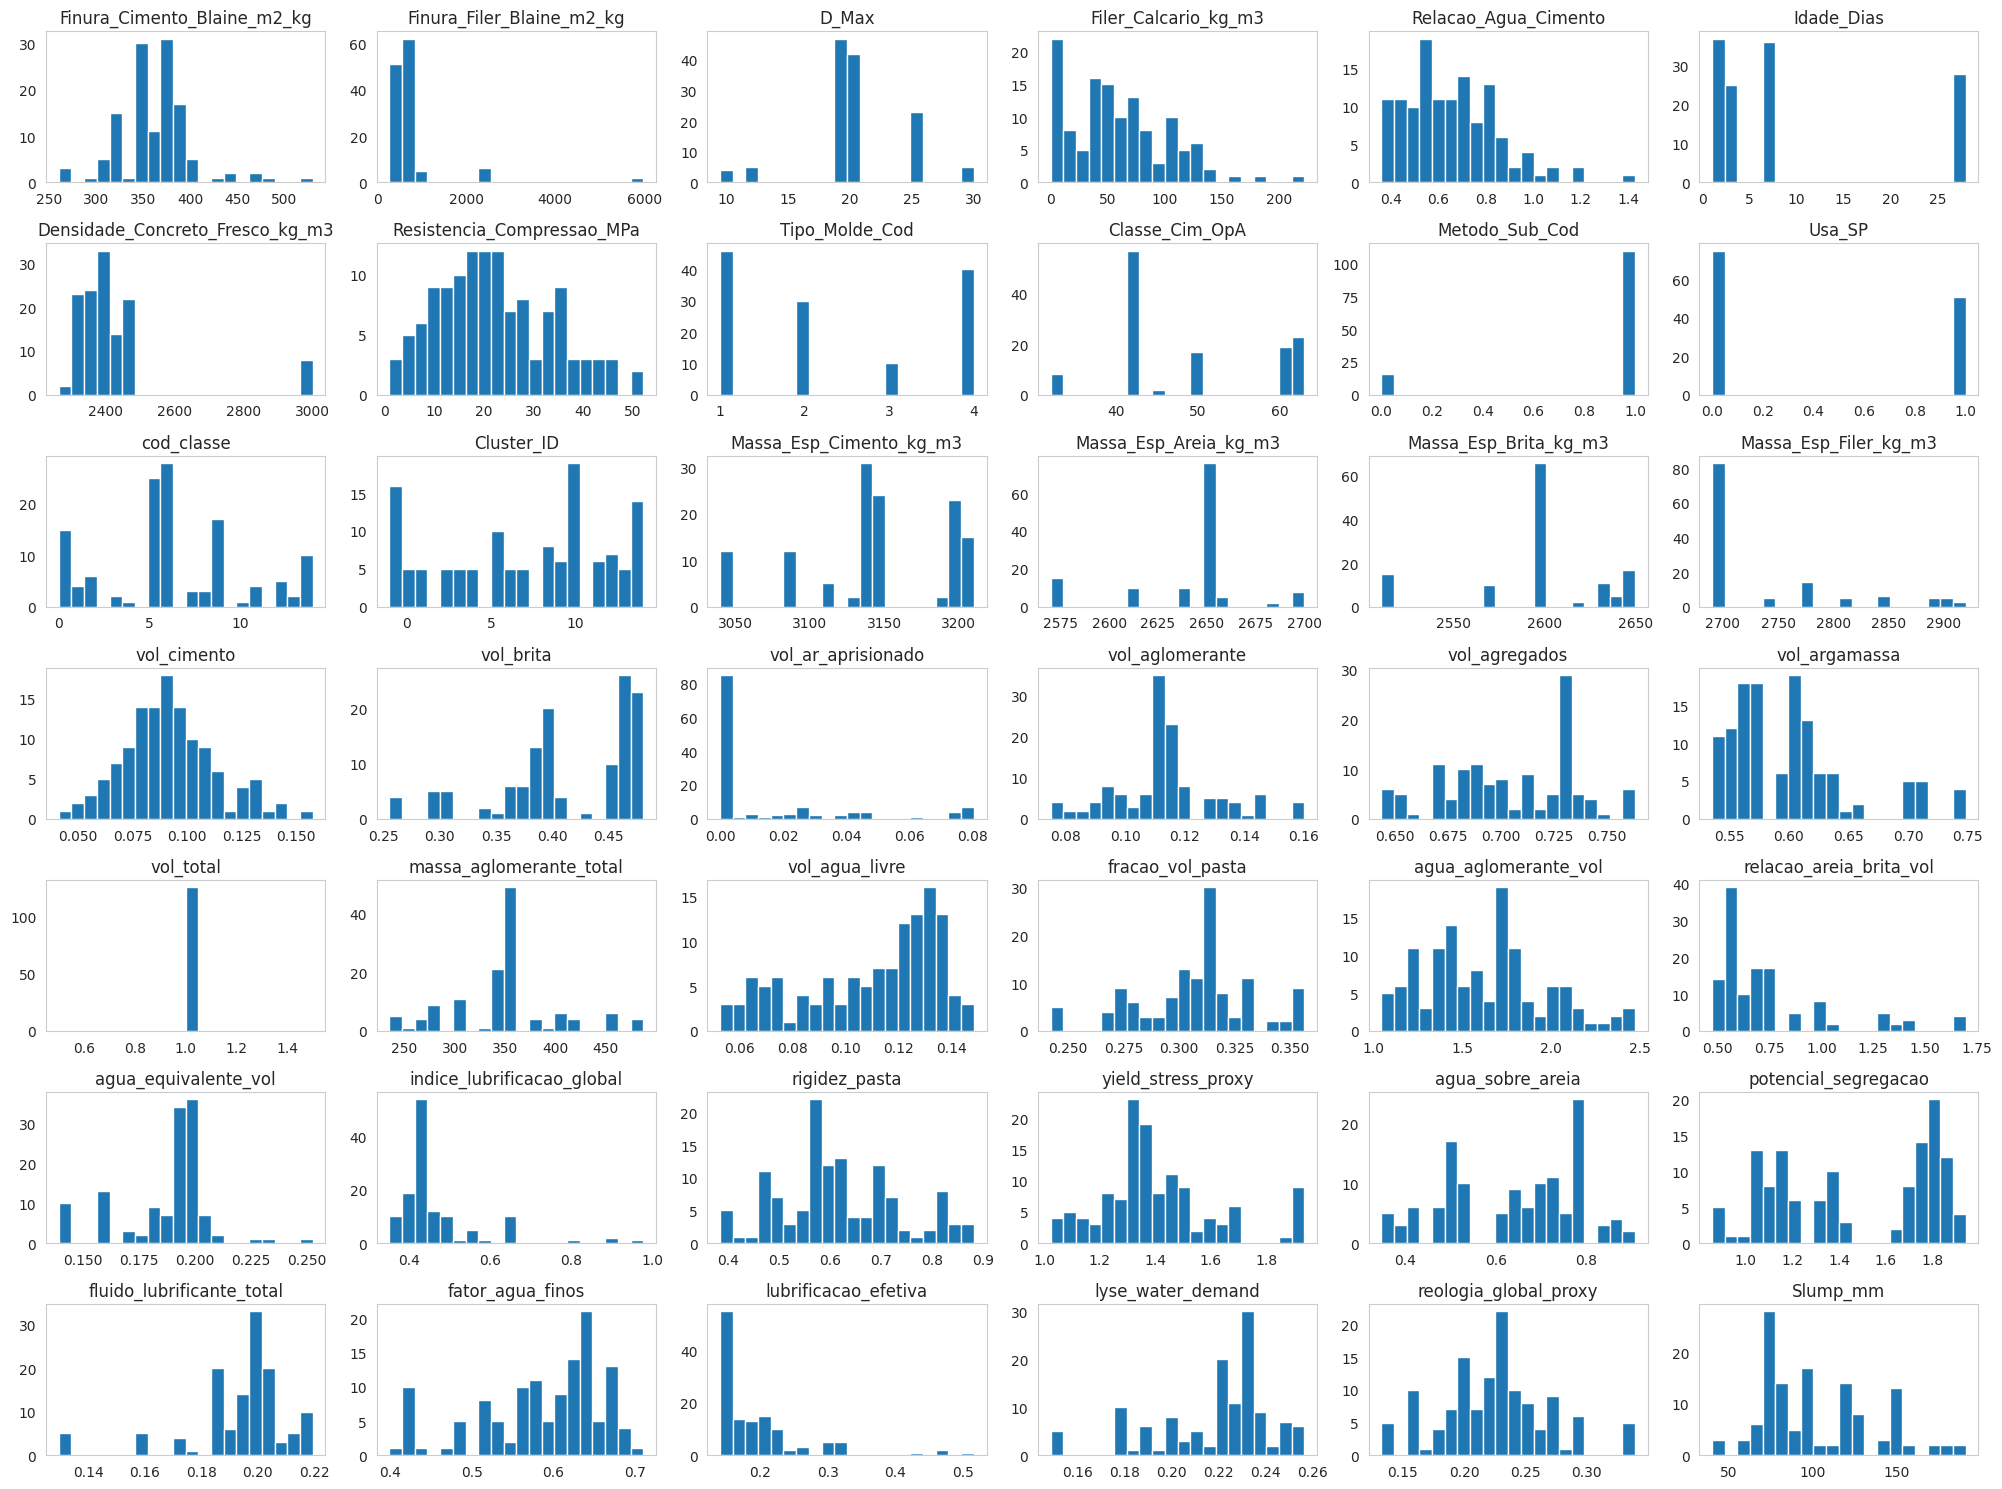

In [ ]:
df_final.hist(bins=20, figsize=(20, 15), grid=False)
plt.tight_layout()
plt.show()

In [ ]:
df_final.to_pickle(os.path.join(base_dir + "/slump", f'df_slump_{nome_modelo}.pkl'))